In [1]:
import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [2]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
# object인 datetime 컬럼을 나누기
# pd.to_datetime() 엑셀에서 str을 날짜형식으로 바꿔주는 함수
train['datetime'] = pd.to_datetime(train['datetime'])
#train['datetime'].dt.year은 datetime을 날짜형식으로 변환했을 때 year을 가져오는 속성! 
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

#기존 datetime 컬럼 정보 무시
train = train.iloc[:, 1:]
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   casual      10886 non-null  int64  
 9   registered  10886 non-null  int64  
 10  count       10886 non-null  int64  
 11  year        10886 non-null  int32  
 12  month       10886 non-null  int32  
 13  day         10886 non-null  int32  
 14  hour        10886 non-null  int32  
 15  minute      10886 non-null  int32  
 16  second      10886 non-null  int32  
dtypes: float64(3), int32(6), int64(8)
memory usage: 1.2 MB


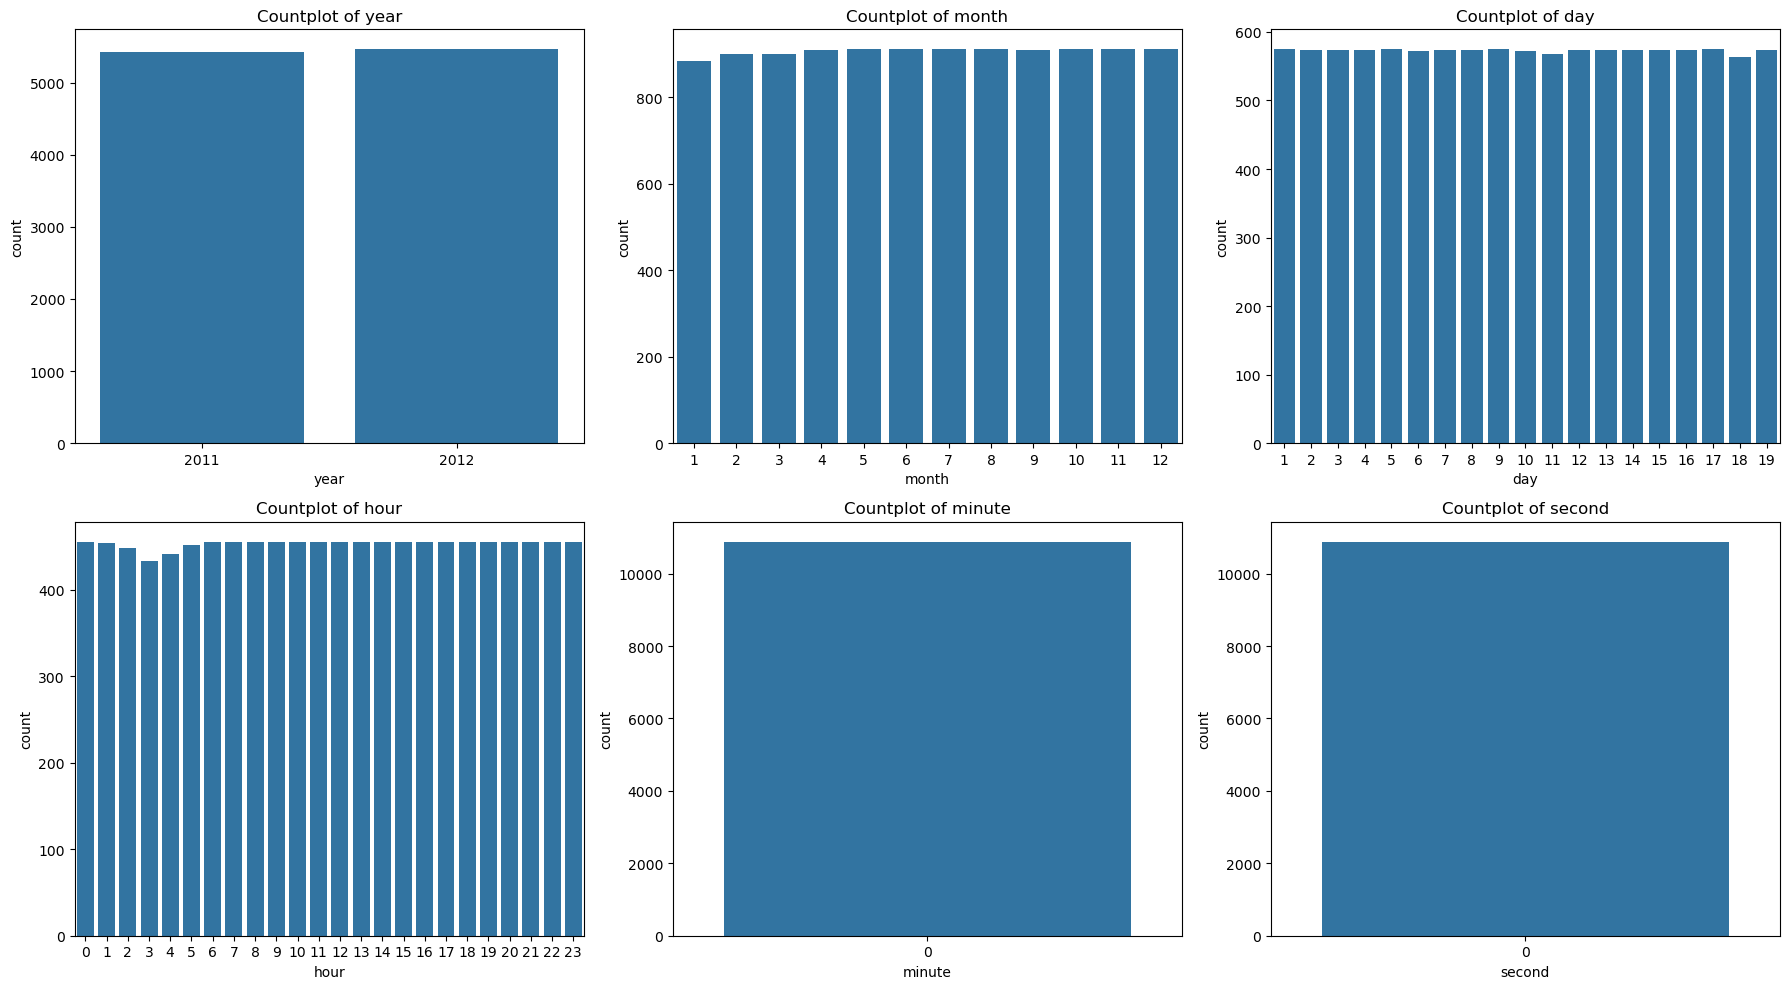

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# year, month, day 등 데이터 개수 시각화
# 여러 도화지 한번에지정하기
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']

for ax, col in zip(axs.flatten(), cols):
    # zip은 두 개의 리스트를 지퍼처럼 하나씩 짝지어 주는 함수
    #flatten은 2x3행렬의 axs를 1x6으로 펼쳐 리스트화
    
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')

#그래프들끼리 제목이나 축 이름이 겹치지 않게 간격을 예쁘게 자동으로 조절해줘!
plt.tight_layout()

plt.show()

#4월부터 많아지고 오전 4시 외에는 거의 시간대가 비슷함..?

In [5]:
#train/test set 분리

features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

# X = train[features].values 넘파이 배열로 안바꿔줘도, sklearn model이 알아서 바꿔줌!
# 머신러닝 공부를 하실 때는 판다스 형태를 유지하는 게 훨씬 유리
# values는 연산 속도가 극도로 중요할 때나, 딥러닝 프레임워크(TensorFlow, PyTorch) 등 넘파이 배열만 엄격하게 받는 라이브러리로 데이터를 넘길 때 주로 사용

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435438
RMSE: 141.2865946027274


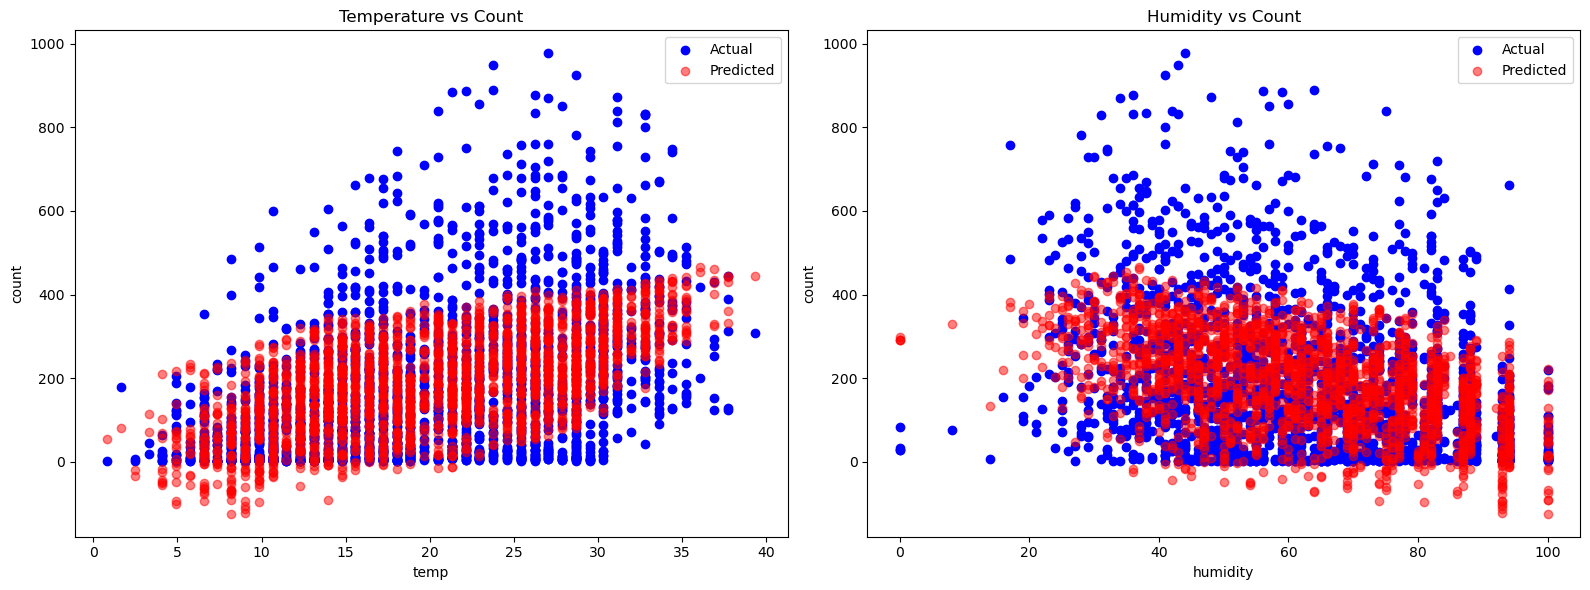

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

plt.tight_layout()
plt.show()

#온도는 5도에서 30도 사이에서 어느정도 선형패턴보이나.. 다른 요인들이 더 많이 영향준는듯..?
#습도는 20 ~ 80에서 균등분포임. 선형아님..


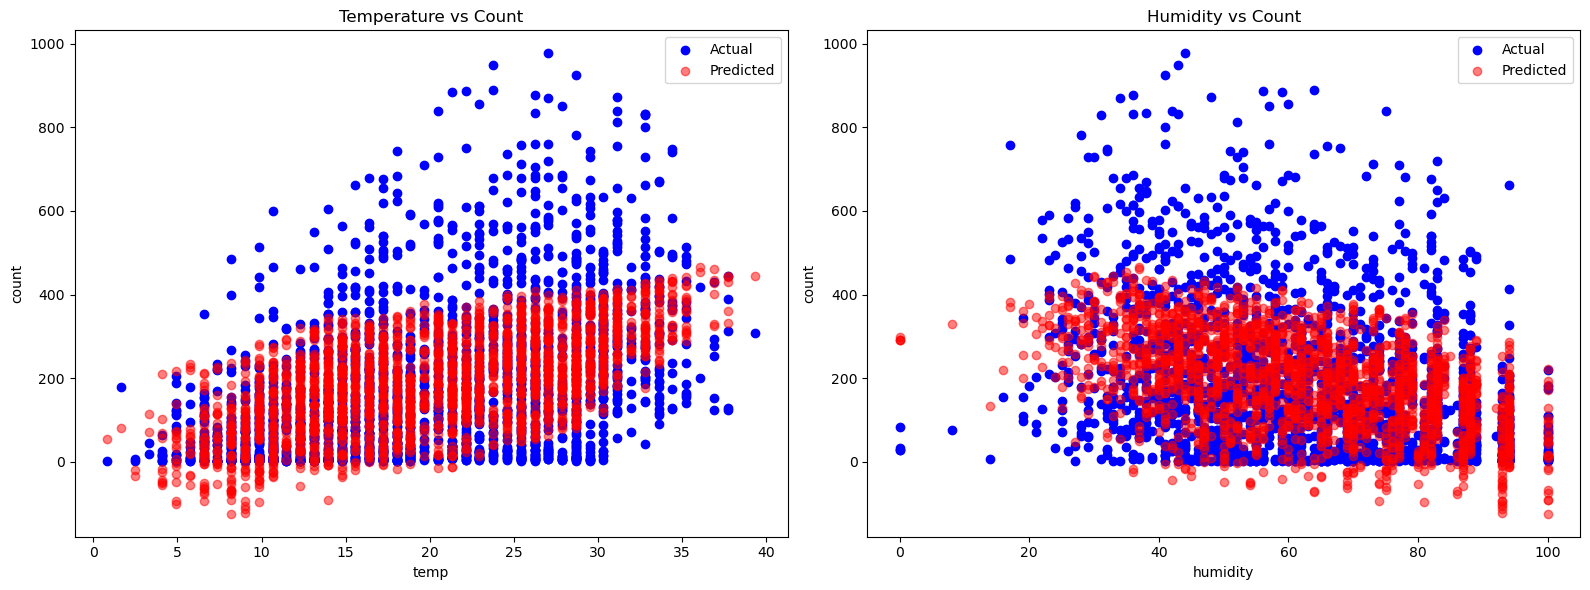

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# hour vs count 시각화
axs[0].scatter(X_test['hour'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['hour'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('hour')
axs[0].set_ylabel('count')
axs[0].set_title('hour vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

plt.tight_layout()
plt.show()

#온도는 5도에서 30도 사이에서 어느정도 선형패턴보이나.. 다른 요인들이 더 많이 영향준는듯..?
#습도는 20 ~ 80에서 균등분포임. 선형아님..


In [10]:
#피처들 정규화 스케일링 하기
#**회귀 모델(Lasso, Ridge)**이나 서포트 벡터 머신(SVM), 로지스틱 회귀처럼 가중치를 계산하는 모델에 필수
# 이상치(Outlier)가 있을 때 유리
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

#오.. 피처들 정규화해서 기온이 0~1로 작아지면 가중치 W를 크게 (예: x30) 잡아서 보상..
#즉 l1, l2 정규화 없이 피처 정규화 해도 회귀모델에서 결과는 변하지 않음..

MSE: 19961.90181443549
RMSE: 141.28659460272758


In [12]:
from sklearn.linear_model import Lasso

# alpha는 규제의 강도(기본값은 1.0, 작게 조정하며 테스트 필)
model_lasso = Lasso(alpha=1.0)
model_lasso.fit(X_train_scaled, y_train)

# 예측
y_pred = model_lasso.predict(X_test_scaled)

In [13]:
# 가중치(Coefficient) 확인
for col, coef in zip(X_train.columns, model_lasso.coef_):
    print(f"{col}: {coef:.4f}")

year: 40.2218
month: 25.3338
day: 0.2982
hour: 53.6873
temp: 50.2551
humidity: -39.7893
windspeed: 1.5466


In [14]:
# Lasso(라쏘) 자체가 이미 하나의 '독립적인 회귀 모델'입니다. 따라서 Lasso로 학습을 마쳤다면, 거기서 바로 predict를 하고 MSE를 확인
# Lasso는 일반 선형 회귀와 똑같은 기본 식($y = Wx + b$)을 가지고 있습니다. 다만, 학습하는 과정에서 **"가중치($W$)가 너무 커지지 않게 감시하는 규칙"**이 추가된 것뿐
# LinearRegression: 오직 오차(MSE)를 줄이는 데만 집중
# Lasso: 오차(MSE)도 줄이면서, **가중치들의 절대값 합(L1 규제)**도 최소화하려고 노력

In [15]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19982.570803322596
RMSE: 141.35972129048145


In [23]:
#L2모델

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=10)

ridge_model.fit(X_train_scaled, y_train)

# 예측
y_pred = ridge_model.predict(X_test_scaled)

In [24]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

#linear, lasso, ridge가 별차이없는 걸 보니 비선형인 듯.

MSE: 19962.057537600584
RMSE: 141.28714569132106


In [25]:
from sklearn.ensemble import RandomForestRegressor

# 모델 생성 (나무 100그루, CPU 전부 사용)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 학습 (기존 데이터 그대로 사용 가능)
rf_model.fit(X_train, y_train)

# 예측 및 RMSE 확인
y_pred = rf_model.predict(X_test)

In [26]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 6538.149249908173
RMSE: 80.85882295648493
